In [10]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import pandas as pd

In [11]:
iris = load_iris()
dir(iris)

['DESCR',
 'data',
 'data_module',
 'feature_names',
 'filename',
 'frame',
 'target',
 'target_names']

In [12]:
df = pd.DataFrame(iris.data,columns = iris.feature_names)
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [13]:
df['target'] = iris.target
df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2
146,6.3,2.5,5.0,1.9,2
147,6.5,3.0,5.2,2.0,2
148,6.2,3.4,5.4,2.3,2


In [14]:
df = df.drop(['sepal length (cm)','sepal width (cm)'],axis = 'columns')
df

,petal length (cm),petal width (cm),target
0,1.4,0.2,0
1,1.4,0.2,0
2,1.3,0.2,0
3,1.5,0.2,0
4,1.4,0.2,0
...,...,...,...
145,5.2,2.3,2
146,5.0,1.9,2
147,5.2,2.0,2
148,5.4,2.3,2


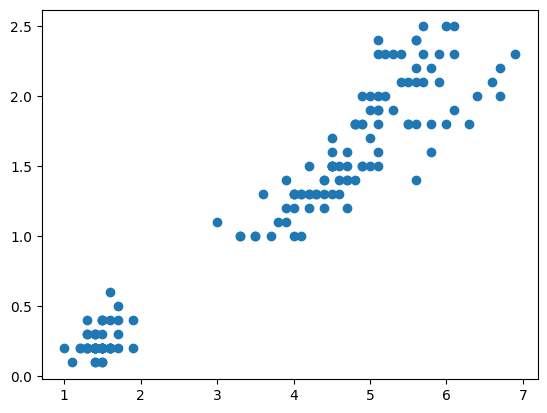

In [15]:
plt.scatter(df['petal length (cm)'],df['petal width (cm)'])
plt.show()

In [17]:
km = KMeans(n_clusters=3)
y_predict = km.fit_predict(df[['petal length (cm)','petal width (cm)']])
y_predict

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int32)

In [18]:
df['Cluster'] = y_predict
df.head(10)

,petal length (cm),petal width (cm),target,Cluster
0,1.4,0.2,0,1
1,1.4,0.2,0,1
2,1.3,0.2,0,1
3,1.5,0.2,0,1
4,1.4,0.2,0,1
5,1.7,0.4,0,1
6,1.4,0.3,0,1
7,1.5,0.2,0,1
8,1.4,0.2,0,1
9,1.5,0.1,0,1


In [35]:
km.cluster_centers_

array([[0.81779661, 0.703125  ],
       [0.08792373, 0.11458333],
       [0.49016949, 0.45      ],
       [0.80037665, 0.86111111],
       [0.6779661 , 0.73888889],
       [0.62209667, 0.56635802],
       [0.07377866, 0.03553922],
       [0.76733436, 0.95075758],
       [0.95932203, 0.84166667]])

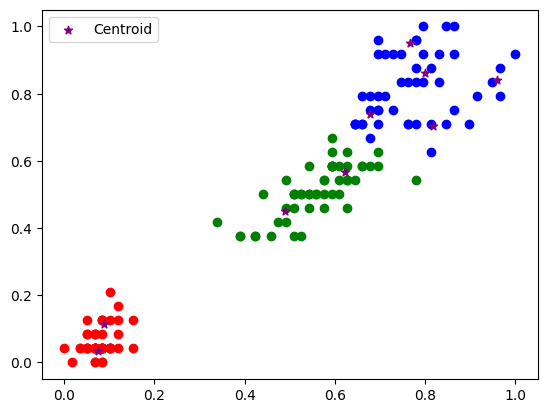

In [36]:
df1 = df[df.Cluster == 0]
df2 = df[df.Cluster == 1]
df3 = df[df.Cluster == 2]

plt.scatter(df1['petal length (cm)'],df1['petal width (cm)'],color = 'Green')
plt.scatter(df2['petal length (cm)'],df2['petal width (cm)'],color = 'Red')
plt.scatter(df3['petal length (cm)'],df3['petal width (cm)'],color = 'Blue')
plt.scatter(km.cluster_centers_[:,0],km.cluster_centers_[:,1],color = 'purple',marker = '*',label = 'Centroid')
plt.legend()

In [21]:
sse = []
k_rng = range(1,10)
for k in k_rng:
    km = KMeans(n_clusters=k)
    km.fit(df)
    sse.append(km.inertia_)

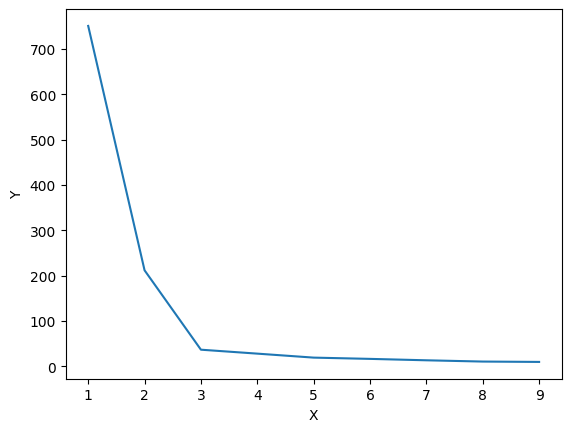

In [22]:
plt.xlabel('X')
plt.ylabel('Y')
plt.plot(k_rng,sse)
plt.show()

In [23]:
scaler = MinMaxScaler()
cols = ['petal length (cm)', 'petal width (cm)']
df[cols] = scaler.fit_transform(df[cols])
df.head()

,petal length (cm),petal width (cm),target,Cluster
0,0.067797,0.041667,0,1
1,0.067797,0.041667,0,1
2,0.050847,0.041667,0,1
3,0.084746,0.041667,0,1
4,0.067797,0.041667,0,1


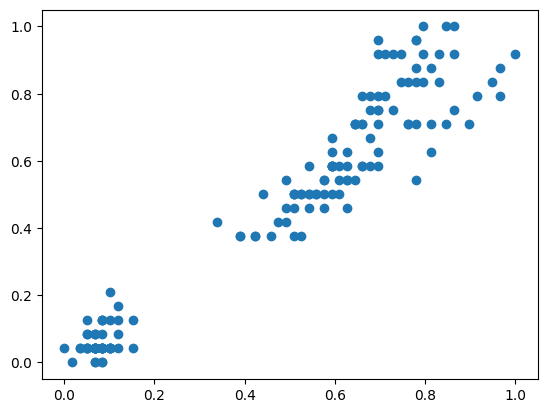

In [24]:
plt.scatter(df['petal length (cm)'],df['petal width (cm)'])
plt.show()

In [29]:
km1 = KMeans(n_clusters=3)
y_predict1 = km1.fit_predict(df[['petal length (cm)','petal width (cm)']])
y_predict1

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 0, 0, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2], dtype=int32)

In [30]:
df['Cluster'] = y_predict1

In [31]:
df.Cluster.unique()

array([1, 0, 2], dtype=int32)

In [33]:
km1.cluster_centers_

array([[0.55867014, 0.51041667],
       [0.07830508, 0.06083333],
       [0.7740113 , 0.81510417]])

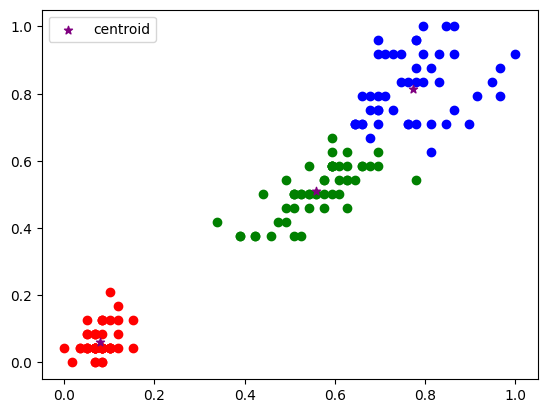

In [34]:
df1 = df[df.Cluster == 0]
df2 = df[df.Cluster == 1]
df3 = df[df.Cluster == 2]

plt.scatter(df1['petal length (cm)'],df1['petal width (cm)'],color = 'Green')
plt.scatter(df2['petal length (cm)'],df2['petal width (cm)'],color = 'Red')
plt.scatter(df3['petal length (cm)'],df3['petal width (cm)'],color = 'Blue')
plt.scatter(km1.cluster_centers_[:,0],km1.cluster_centers_[:,1],color = 'Purple',marker = '*',label = 'centroid')
plt.legend()